## Import needed library:
### We need following library:
- pandas
- numpy
- matplotlib
- seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Define file path to pandas and see some information about our CSV dataframe:

In [2]:
df = pd.read_csv('../data/daily/Binance_BTCUSDT_d.csv')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3101 entries, 0 to 3100
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unix         3101 non-null   int64  
 1   Date         3101 non-null   str    
 2   Symbol       3101 non-null   str    
 3   Open         3101 non-null   float64
 4   High         3101 non-null   float64
 5   Low          3101 non-null   float64
 6   Close        3101 non-null   float64
 7   Volume BTC   3101 non-null   float64
 8   Volume USDT  3101 non-null   float64
 9   tradecount   3101 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 242.4 KB


### Convert Date column from sting to datetype:

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Unix                    int64
Date           datetime64[us]
Symbol                    str
Open                  float64
High                  float64
Low                   float64
Close                 float64
Volume BTC            float64
Volume USDT           float64
tradecount              int64
dtype: object

### See the correlation matrix for numeric columns of dataframe:

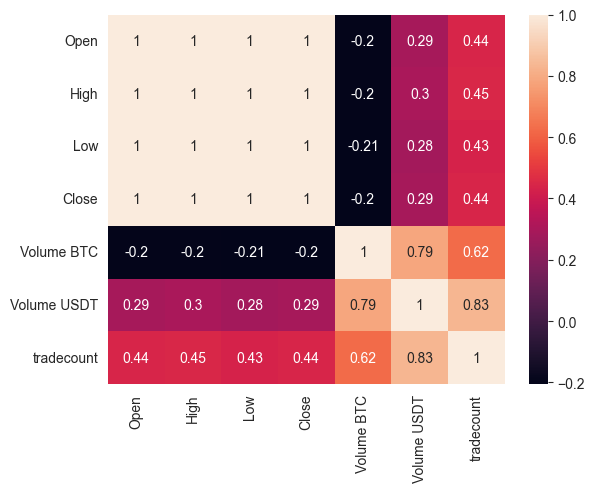

In [4]:
corr = df[['Open', 'High'
,'Low'
, 'Close'
, 'Volume BTC'
, 'Volume USDT'
, 'tradecount']].corr()
sns.heatmap(corr, annot=True)
plt.show()

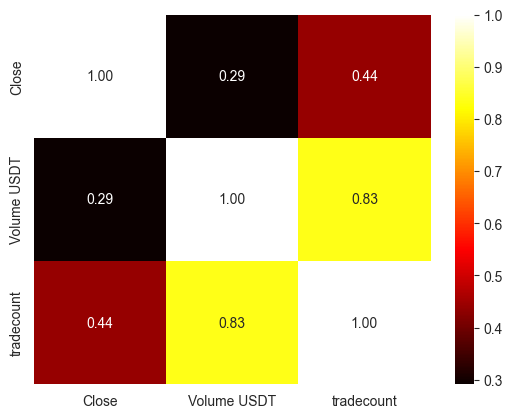

In [5]:
corr2 = df[['Close', 'Volume USDT', 'tradecount']].corr()
sns.heatmap(corr2, annot=True, cmap='hot', fmt='.2f')
plt.show()

### Creating target column:

In [6]:
df['Target'] = df['Close'].shift(1)
df.to_csv('../data/daily/BTCUSDT_d.csv', index=False)
df.head()

,Unix,Date,Symbol,Open,High,Low,Close,Volume BTC,Volume USDT,tradecount,Target
0,1770940800000,2026-02-13,BTCUSDT,66272.17,69482.97,65872.46,68853.96,20244.54955,1.371286e+09,6450842,NaN
1,1770854400000,2026-02-12,BTCUSDT,67082.52,68410.52,65118.00,66272.17,24271.74283,1.622162e+09,6778280,68853.96
2,1770768000000,2026-02-11,BTCUSDT,68841.28,69292.88,65756.00,67082.52,28718.24602,1.930514e+09,6956577,66272.17
3,1770681600000,2026-02-10,BTCUSDT,70138.00,70527.59,67800.00,68841.29,20373.77072,1.408624e+09,4558658,67082.52
4,1770595200000,2026-02-09,BTCUSDT,70330.38,71453.53,68308.00,70138.00,29152.72842,2.038960e+09,6644769,68841.29


In [7]:
new_df = pd.read_csv('../data/daily/BTCUSDT_d.csv')
new_df.isnull().sum()

Unix           0
Date           0
Symbol         0
Open           0
High           0
Low            0
Close          0
Volume BTC     0
Volume USDT    0
tradecount     0
Target         1
dtype: int64

### Removing null row:

In [8]:
new_df.dropna(inplace=True)
new_df.isnull().sum()

Unix           0
Date           0
Symbol         0
Open           0
High           0
Low            0
Close          0
Volume BTC     0
Volume USDT    0
tradecount     0
Target         0
dtype: int64

In [9]:
new_df['Date'] = pd.to_datetime(new_df['Date'])
new_df.dtypes

Unix                    int64
Date           datetime64[us]
Symbol                    str
Open                  float64
High                  float64
Low                   float64
Close                 float64
Volume BTC            float64
Volume USDT           float64
tradecount              int64
Target                float64
dtype: object

### Separate data to train RF model:

In [10]:
x = new_df[['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount']]
y = new_df['Target']

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=False)

In [12]:
len(x_train), len(x_test), len(y_train), len(y_test)

(2480, 620, 2480, 620)

### Train RFR with separated data:

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

print("RandomForestRegressor were successfully trained.")

RandomForestRegressor were successfully trained.


In [14]:
y_pred = model.predict(x_test)

In [15]:
y_pred

array([ 5450.24641667,  5507.35491667,  5421.56575   ,  5524.53166667,
        5784.92791667,  5785.99708333,  5408.748     ,  5413.64158333,
        5408.11575   ,  5383.89583333,  5347.45675   ,  5332.78891667,
        5355.40608333,  5359.98041667,  5356.99375   ,  5356.40575   ,
        5363.79733333,  5422.65641667,  5371.29458333,  5389.82141667,
        5356.66766667,  5363.25491667,  5359.28941667,  5364.34066667,
        5378.05658333,  5361.91025   ,  5372.214     ,  5355.3355    ,
        5371.06391667,  5363.6905    ,  5379.36416667,  5361.76216667,
        5380.73208333,  5379.36416667,  5381.90666667,  5371.06391667,
        5371.06391667,  5361.76216667,  5382.52041667,  5362.99758333,
        5361.76216667,  5365.86525   ,  5363.6905    ,  5373.71908333,
        5365.86525   ,  5370.72208333,  5363.5175    ,  5357.34583333,
        5382.52041667,  5365.86525   ,  5379.36416667,  5382.52041667,
        5357.34583333,  5366.479     ,  5380.53875   ,  5381.90666667,
      

In [16]:
from sklearn.metrics import mean_absolute_error

mea = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mea)

Mean Absolute Error: 725.3880501344079


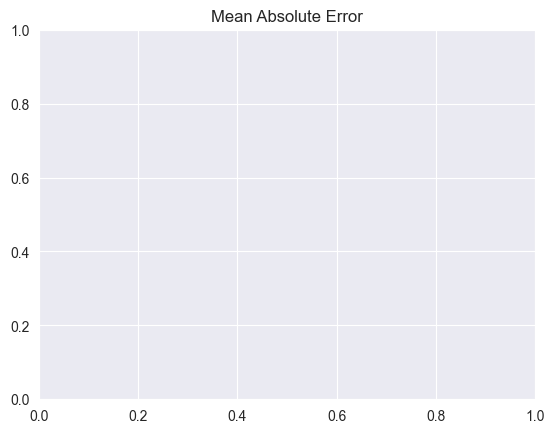

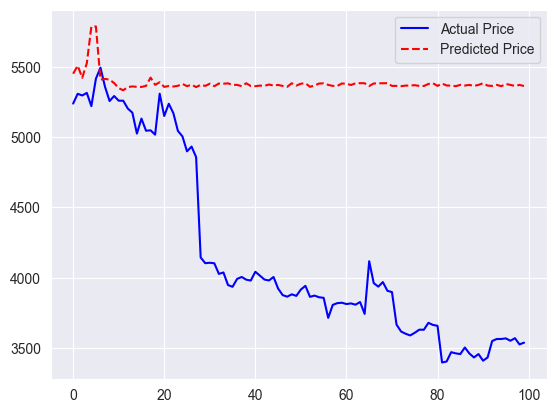

In [17]:
plt.title('Mean Absolute Error')
plt.figure()
plt.plot(y_test.values[:100], label='Actual Price', color='blue')
plt.plot(y_pred[:100], label='Predicted Price', color='red', linestyle='--')
plt.legend()
plt.show()

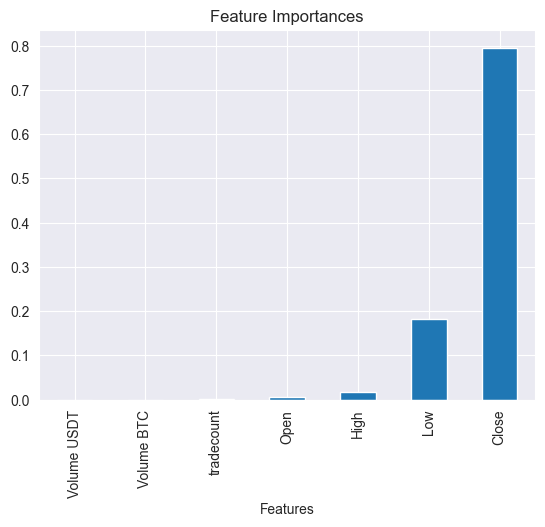

In [18]:
importances = model.feature_importances_
features = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount']
feature_importance_df = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure()
feature_importance_df.plot(kind='bar')
plt.xlabel('Features')
plt.title('Feature Importances')
plt.show()

In [19]:
delta = new_df['Close'].diff()
delta

1           NaN
2        810.35
3       1758.77
4       1296.71
5        192.38
         ...   
3096     -24.00
3097      70.29
3098      53.69
3099     -31.61
3100     176.71
Name: Close, Length: 3100, dtype: float64

In [23]:
gain = delta.where(delta > 0, 0)
gain

1          0.00
2        810.35
3       1758.77
4       1296.71
5        192.38
         ...   
3096       0.00
3097      70.29
3098      53.69
3099       0.00
3100     176.71
Name: Close, Length: 3100, dtype: float64

In [24]:
loss = delta.where(delta < 0, 0)
loss

1        0.00
2        0.00
3        0.00
4        0.00
5        0.00
        ...  
3096   -24.00
3097     0.00
3098     0.00
3099   -31.61
3100     0.00
Name: Close, Length: 3100, dtype: float64

In [27]:
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
avg_gain.head(20)

1             NaN
2             NaN
3             NaN
4             NaN
5             NaN
6             NaN
7             NaN
8             NaN
9             NaN
10            NaN
11            NaN
12            NaN
13            NaN
14    2033.580000
15    2061.413571
16    2335.662143
17    2210.035714
18    2117.413571
19    2103.672143
20    2286.170714
Name: Close, dtype: float64

In [28]:
RS = avg_gain / avg_loss
new_df['RSI'] = 100 - (100 / (1 + RS))
new_df.to_csv('../data/daily/BTCUSDT_d+RSI.csv', index=False)

In [29]:
df_with_rsi = pd.read_csv('../data/daily/BTCUSDT_d+RSI.csv')
df_with_rsi.head(20)

,Unix,Date,Symbol,Open,High,Low,Close,Volume BTC,Volume USDT,tradecount,Target,RSI
0,1770854400000,2026-02-12,BTCUSDT,67082.52,68410.52,65118.00,66272.17,24271.74283,1.622162e+09,6778280,68853.96,NaN
1,1770768000000,2026-02-11,BTCUSDT,68841.28,69292.88,65756.00,67082.52,28718.24602,1.930514e+09,6956577,66272.17,NaN
2,1770681600000,2026-02-10,BTCUSDT,70138.00,70527.59,67800.00,68841.29,20373.77072,1.408624e+09,4558658,67082.52,NaN
3,1770595200000,2026-02-09,BTCUSDT,70330.38,71453.53,68308.00,70138.00,29152.72842,2.038960e+09,6644769,68841.29,NaN
4,1770508800000,2026-02-08,BTCUSDT,69289.37,72271.41,68888.00,70330.38,21420.53168,1.510004e+09,4870449,70138.00,NaN
5,1770422400000,2026-02-07,BTCUSDT,70580.26,71690.07,67300.00,69289.38,44255.48036,3.058984e+09,7167427,70330.38,NaN
6,1770336000000,2026-02-06,BTCUSDT,62909.87,71751.33,60000.00,70580.26,92539.21531,6.134057e+09,13228528,69289.38,NaN
7,1770249600000,2026-02-05,BTCUSDT,73165.84,73341.18,62345.00,62909.86,106298.82899,7.198746e+09,15364010,70580.26,NaN
8,1770163200000,2026-02-04,BTCUSDT,75770.21,76971.52,71888.00,73165.83,38375.36000,2.852835e+09,10724002,62909.86,NaN
9,1770076800000,2026-02-03,BTCUSDT,78738.60,79186.81,72945.50,75770.21,39120.10889,2.986903e+09,9199445,73165.83,NaN


In [31]:
df_with_rsi['Date'] = pd.to_datetime(df_with_rsi['Date'])

In [32]:
df_with_rsi.dropna(inplace=True)

In [40]:
x = df_with_rsi[['Open', 'High', 'Low', 'Close', 'RSI', 'Volume BTC', 'Volume USDT', 'tradecount']]
y = df_with_rsi['Target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

print("RandomForestRegressor with RSI were successfully trained.")

RandomForestRegressor with RSI were successfully trained.


In [43]:
y_pred = model.predict(x_test)

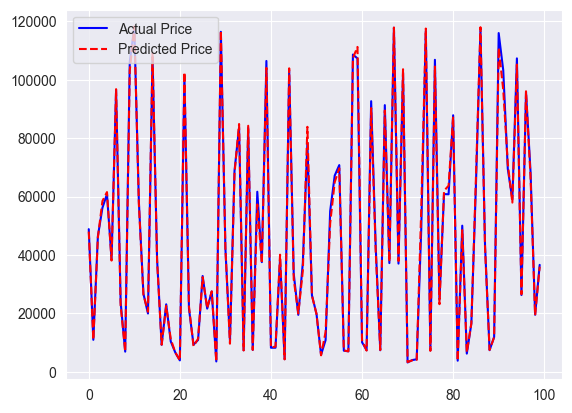

In [44]:

plt.figure()
plt.plot(y_test.values[:100], label='Actual Price', color='blue')
plt.plot(y_pred[:100], label='Predicted Price', color='red', linestyle='--')
plt.legend()
plt.show()

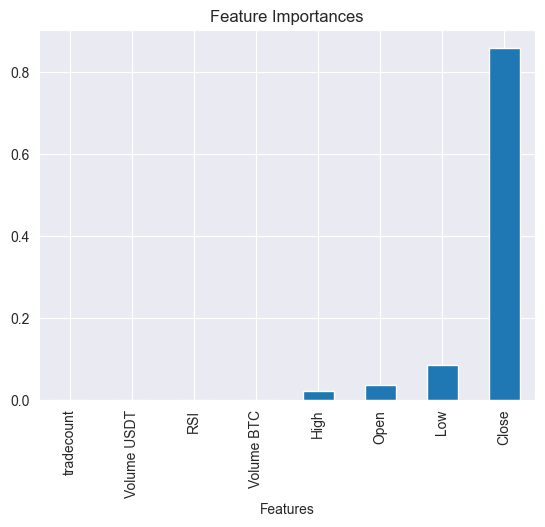

In [45]:
importances = model.feature_importances_
features = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount', 'RSI']
feature_importance_df = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure()
feature_importance_df.plot(kind='bar')
plt.xlabel('Features')
plt.title('Feature Importances')
plt.show()

In [46]:
df_with_rsi['MA5'] = df_with_rsi['Close'].rolling(window=5).mean()

In [47]:
df_with_rsi['MA5'].head(20)

13          NaN
14          NaN
15          NaN
16          NaN
17    87161.544
18    87643.518
19    88558.554
20    88618.608
21    88680.542
22    88902.072
23    90094.200
24    90983.760
25    92093.262
26    93291.516
27    94521.530
28    95385.686
29    95733.858
30    94963.544
31    94056.086
32    93036.066
Name: MA5, dtype: float64

In [48]:
df_with_rsi['MA20'] = df_with_rsi['Close'].rolling(window=20).mean()
df_with_rsi['MA20'].head(20)

13          NaN
14          NaN
15          NaN
16          NaN
17          NaN
18          NaN
19          NaN
20          NaN
21          NaN
22          NaN
23          NaN
24          NaN
25          NaN
26          NaN
27          NaN
28          NaN
29          NaN
30          NaN
31          NaN
32    90905.303
Name: MA20, dtype: float64

In [49]:
df_with_rsi.to_csv('../data/daily/BTCUSDT_d+MA.csv', index=False)

In [50]:
df_with_ma = pd.read_csv('../data/daily/BTCUSDT_d+MA.csv')

In [51]:
df_with_ma.columns

Index(['Unix', 'Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume BTC',
       'Volume USDT', 'tradecount', 'Target', 'RSI', 'MA5', 'MA20'],
      dtype='str')

In [52]:
x = df_with_ma[['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount', 'RSI', 'MA5', 'MA20']]
y = df_with_ma['Target']

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [54]:
RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

print("RandomForestRegressor with RSI were successfully trained.")

RandomForestRegressor with RSI were successfully trained.


In [55]:
y_pred = model.predict(x_test)

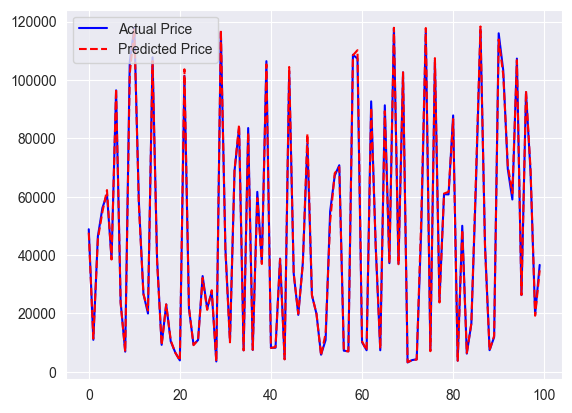

In [56]:
plt.figure()
plt.plot(y_test.values[:100], label='Actual Price', color='blue')
plt.plot(y_pred[:100], label='Predicted Price', color='red', linestyle='--')
plt.legend()
plt.show()

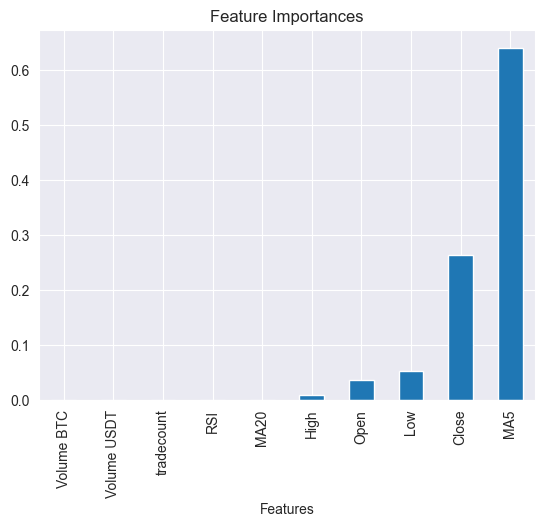

In [58]:
importances = model.feature_importances_
features = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount', 'RSI', 'MA5', 'MA20']
feature_importance_df = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure()
feature_importance_df.plot(kind='bar')
plt.xlabel('Features')
plt.title('Feature Importances')
plt.show()